In [21]:
# Import pandas for data handling
import pandas as pd

# Load the dataset
df = pd.read_csv('student_data.csv')
df.head()




,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [22]:
# Select relevant features for clustering
# These features represent behavior, performance, and lifestyle
features = ['studytime', 'failures', 'absences', 'G3', 'goout', 'freetime']


# Create a new dataset with selected features
X = df[features]

In [23]:
# Import scaler to normalize the data
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview scaled data
print(X_scaled[:5])

[[-0.04228585 -0.44994364  0.03642446 -0.96493392  0.8014793  -0.2360102 ]
 [-0.04228585 -0.44994364 -0.21379577 -0.96493392 -0.09790798 -0.2360102 ]
 [-0.04228585  3.58932316  0.53686493 -0.0907392  -0.99729526 -0.2360102 ]
 [ 1.15077909 -0.44994364 -0.464016    1.0020042  -0.99729526 -1.23841914]
 [-0.04228585 -0.44994364 -0.21379577 -0.0907392  -0.99729526 -0.2360102 ]]


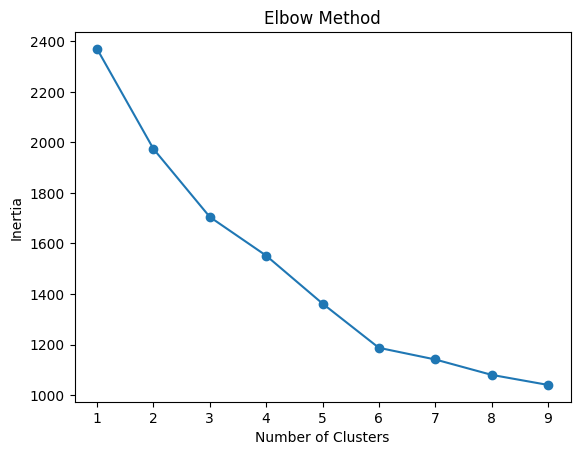

In [24]:
# Import KMeans and plotting library
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# Store inertia values for different k values
inertia = []


# Try different numbers of clusters (k=1 to 9)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


# Plot the elbow curve
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [25]:
# Choose optimal number of clusters (k=4 based on elbow method)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataset
df['Cluster'] = clusters

In [26]:
# Calculate mean values of each feature for each cluster
# This helps interpret what each cluster represents
df.groupby('Cluster')[['studytime', 'failures', 'absences', 'G3', 'goout', 'freetime']].mean()

,studytime,failures,absences,G3,goout,freetime
Cluster,,,,,,
0,2.194595,0.048649,4.162162,12.740541,2.432432,2.800000
1,1.714286,0.261905,9.761905,10.968254,3.841270,3.857143
2,1.533333,2.533333,5.333333,5.800000,3.633333,3.600000
3,2.518519,0.259259,1.759259,3.722222,3.425926,3.074074


In [27]:
df.groupby('Cluster')[features].mean().round(2)

,studytime,failures,absences,G3,goout,freetime
Cluster,,,,,,
0,2.19,0.05,4.16,12.74,2.43,2.80
1,1.71,0.26,9.76,10.97,3.84,3.86
2,1.53,2.53,5.33,5.80,3.63,3.60
3,2.52,0.26,1.76,3.72,3.43,3.07


Cluster 0 represents students with moderate study time, low absences, and relatively high grades, indicating consistent and focused learners.

Cluster 1 represents socially active students with higher absences and average performance, suggesting that increased social activity may impact consistency.

Cluster 2 represents at-risk students with low study time, higher failures, and poor academic performance.

Cluster 3 represents students with high study effort but low performance, indicating possible learning difficulties or ineffective study methods.

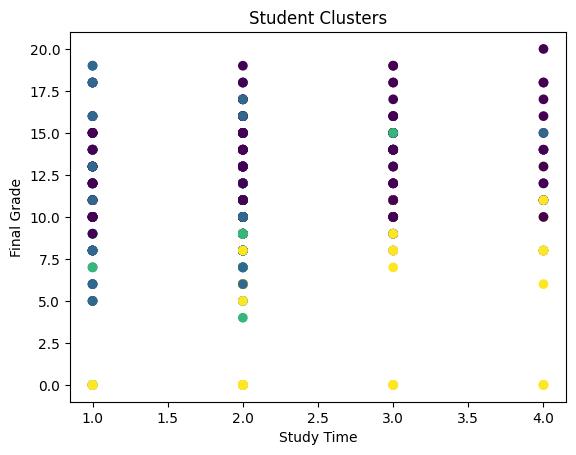

In [28]:
# Visualize clusters using study time vs final grade
# Each color represents a different cluster
import matplotlib.pyplot as plt

plt.scatter(df['studytime'], df['G3'], c=df['Cluster'])
plt.xlabel('Study Time')
plt.ylabel('Final Grade')
plt.title('Student Clusters')
plt.show()

In [29]:
# Import PCA to reduce the scaled data to 2 dimensions for visualization
from sklearn.decomposition import PCA

# Reduce the 6 selected features into 2 PCA components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

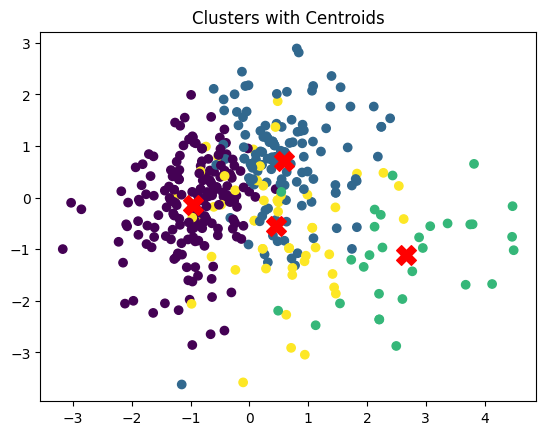

In [30]:
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis')
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200)
plt.title('Clusters with Centroids')
plt.show()